# 머신러닝 분류

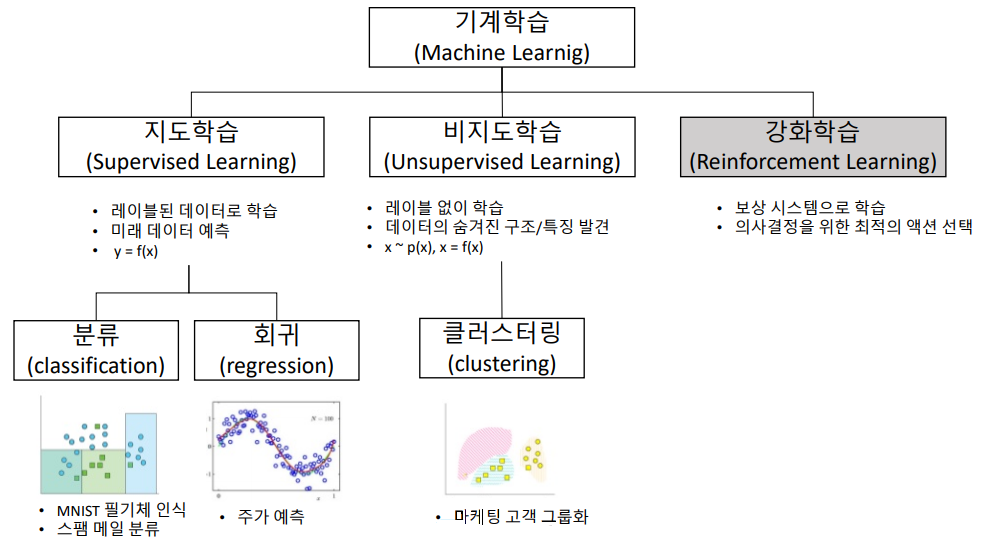

## k-NearestNeighbor(k-최근접이웃) 알고리즘

 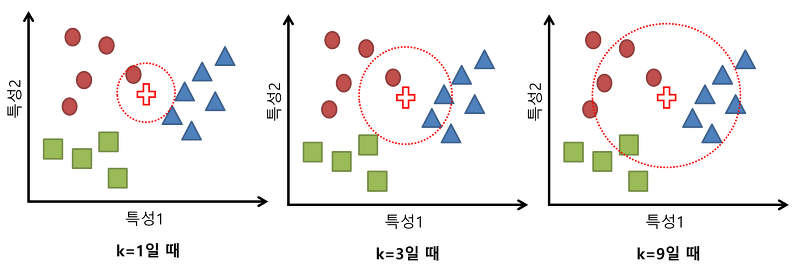

#붓꽃데이터 분류
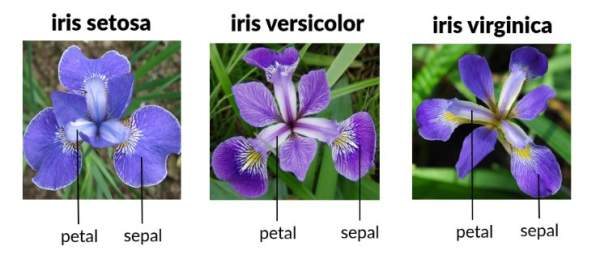

# 데이터 준비

In [2]:
import pandas as pd
import numpy as np

In [ ]:
iris = pd.read_csv('https://raw.githubusercontent.com/wizard113/ML-Basic/main/iris.csv')

In [4]:
iris.head()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.head(10)

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa
5,6,5.4,3.9,1.7,0.4,setosa
6,7,4.6,3.4,1.4,0.3,setosa
7,8,5.0,3.4,1.5,0.2,setosa
8,9,4.4,2.9,1.4,0.2,setosa
9,10,4.9,3.1,1.5,0.1,setosa


In [6]:
iris.tail()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
145,146,6.7,3.0,5.2,2.3,virginica
146,147,6.3,2.5,5.0,1.9,virginica
147,148,6.5,3.0,5.2,2.0,virginica
148,149,6.2,3.4,5.4,2.3,virginica
149,150,5.9,3.0,5.1,1.8,virginica


In [7]:
iris.describe()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.057333,3.758000,1.199333
std,43.445368,0.828066,0.435866,1.765298,0.762238
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   caseno       150 non-null    int64  
 1   SepalLength  150 non-null    float64
 2   SepalWidth   150 non-null    float64
 3   PetalLength  150 non-null    float64
 4   PetalWidth   150 non-null    float64
 5   Species      150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [9]:
iris['Species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: object

In [10]:
iris['PetalLength']

0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: PetalLength, Length: 150, dtype: float64

In [11]:
iris[['PetalLength', 'PetalWidth']]

,PetalLength,PetalWidth
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [12]:
np.unique(iris['Species'], return_counts=True)

(array(['setosa', 'versicolor', 'virginica'], dtype=object),
 array([50, 50, 50]))

In [13]:
iris.columns

Index(['caseno', 'SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth',
       'Species'],
      dtype='object')

In [14]:
iris.values

array([[1, 5.1, 3.5, 1.4, 0.2, 'setosa'],
       [2, 4.9, 3.0, 1.4, 0.2, 'setosa'],
       [3, 4.7, 3.2, 1.3, 0.2, 'setosa'],
       [4, 4.6, 3.1, 1.5, 0.2, 'setosa'],
       [5, 5.0, 3.6, 1.4, 0.2, 'setosa'],
       [6, 5.4, 3.9, 1.7, 0.4, 'setosa'],
       [7, 4.6, 3.4, 1.4, 0.3, 'setosa'],
       [8, 5.0, 3.4, 1.5, 0.2, 'setosa'],
       [9, 4.4, 2.9, 1.4, 0.2, 'setosa'],
       [10, 4.9, 3.1, 1.5, 0.1, 'setosa'],
       [11, 5.4, 3.7, 1.5, 0.2, 'setosa'],
       [12, 4.8, 3.4, 1.6, 0.2, 'setosa'],
       [13, 4.8, 3.0, 1.4, 0.1, 'setosa'],
       [14, 4.3, 3.0, 1.1, 0.1, 'setosa'],
       [15, 5.8, 4.0, 1.2, 0.2, 'setosa'],
       [16, 5.7, 4.4, 1.5, 0.4, 'setosa'],
       [17, 5.4, 3.9, 1.3, 0.4, 'setosa'],
       [18, 5.1, 3.5, 1.4, 0.3, 'setosa'],
       [19, 5.7, 3.8, 1.7, 0.3, 'setosa'],
       [20, 5.1, 3.8, 1.5, 0.3, 'setosa'],
       [21, 5.4, 3.4, 1.7, 0.2, 'setosa'],
       [22, 5.1, 3.7, 1.5, 0.4, 'setosa'],
       [23, 4.6, 3.6, 1.0, 0.2, 'setosa'],
       [24, 5.1, 3.3

In [15]:
type(iris.values)

numpy.ndarray

In [16]:
iris.head()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [17]:
iris = iris[['PetalLength', 'PetalWidth', 'Species']]

In [18]:
iris.head()

,PetalLength,PetalWidth,Species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


In [19]:
setosa = iris[iris.Species=='setosa']
versicolor = iris[iris.Species=='versicolor']
virginica = iris[iris.Species=='virginica']

## Data와 Target분리

In [20]:
iris_input = iris[['PetalLength', 'PetalWidth']]

In [21]:
iris_input.shape

(150, 2)

In [22]:
iris_target = iris['Species']

## Dataframe을 Numpy ndarray로 변환

In [23]:
iris_input = iris_input.to_numpy()
iris_target = iris_target.to_numpy()
print(iris_input)
print(iris_target)

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

In [24]:
iris_input.shape

(150, 2)

In [25]:
import matplotlib.pyplot as plt

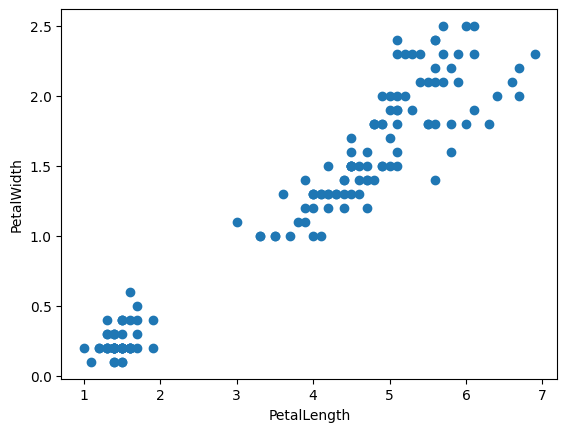

In [26]:
plt.scatter(iris_input[:, 0], iris_input[:, 1])
plt.xlabel('PetalLength')
plt.ylabel('PetalWidth')
plt.show()

In [27]:
setosa = setosa.to_numpy()
versicolor = versicolor.to_numpy()
virginica = virginica.to_numpy()
print(setosa)

[[1.4 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.3 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.7 0.4 'setosa']
 [1.4 0.3 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.5 0.1 'setosa']
 [1.5 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.4 0.1 'setosa']
 [1.1 0.1 'setosa']
 [1.2 0.2 'setosa']
 [1.5 0.4 'setosa']
 [1.3 0.4 'setosa']
 [1.4 0.3 'setosa']
 [1.7 0.3 'setosa']
 [1.5 0.3 'setosa']
 [1.7 0.2 'setosa']
 [1.5 0.4 'setosa']
 [1.0 0.2 'setosa']
 [1.7 0.5 'setosa']
 [1.9 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.6 0.4 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.5 0.4 'setosa']
 [1.5 0.1 'setosa']
 [1.4 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.2 0.2 'setosa']
 [1.3 0.2 'setosa']
 [1.4 0.1 'setosa']
 [1.3 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.3 0.3 'setosa']
 [1.3 0.3 'setosa']
 [1.3 0.2 'setosa']
 [1.6 0.6 'setosa']
 [1.9 0.4 'setosa']
 [1.4 0.3 'setosa']
 [1.6 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']]

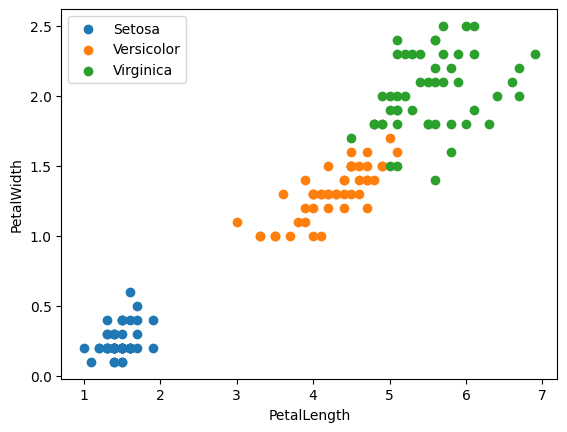

In [28]:
plt.scatter(setosa[:, 0], setosa[:, 1])
plt.scatter(versicolor[:, 0], versicolor[:,1])
plt.scatter(virginica[:, 0], virginica[:,1])
plt.xlabel('PetalLength')
plt.ylabel('PetalWidth')
plt.legend(['Setosa', 'Versicolor', 'Virginica'])
plt.show()

## Train, Test용 데이터분리

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
train_input, test_input, train_target, test_target = \
        train_test_split(iris_input,
                 iris_target,
                 test_size=0.2,
                 random_state=11)

In [31]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(120, 2) (120,)
(30, 2) (30,)


In [ ]:
train_input

## 표준화

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [35]:
train_scaled

array([[-1.31099697, -1.28542494],
       [ 1.09040323,  1.43894078],
       [ 1.6488684 ,  1.04974568],
       [-1.31099697, -1.28542494],
       [-1.19930394, -1.28542494],
       [ 1.76056143,  1.43894078],
       [ 1.59302188,  1.17947738],
       [ 0.69947762,  0.66055058],
       [-1.36684349, -1.28542494],
       [ 0.75532414,  0.53081888],
       [-0.13822013, -0.24757133],
       [ 1.48132885,  1.04974568],
       [-1.31099697, -1.15569323],
       [ 0.6436311 ,  0.40108718],
       [ 1.14624975,  1.30920908],
       [-0.41745271, -0.11783963],
       [ 0.47609155,  0.14162377],
       [-1.42269001, -1.28542494],
       [ 1.3137893 ,  0.92001398],
       [-1.19930394, -1.28542494],
       [ 1.20209627,  1.43894078],
       [ 0.75532414,  1.43894078],
       [ 0.25270549,  0.40108718],
       [ 0.42024504,  0.66055058],
       [ 0.53193807,  0.40108718],
       [-1.36684349, -1.28542494],
       [-1.14345742, -1.28542494],
       [ 0.47609155,  0.40108718],
       [-1.25515046,

# k-최근접 이웃 다중분류

In [36]:
from sklearn.neighbors import KNeighborsClassifier

In [37]:
kn = KNeighborsClassifier()
kn.fit(train_scaled, train_target)

KNeighborsClassifier()

In [38]:
kn.score(test_scaled, test_target)

0.9333333333333333

In [39]:
kn = KNeighborsClassifier(n_neighbors=1)
kn.fit(train_scaled, train_target)
kn.score(test_scaled, test_target)

0.9

In [40]:
k_nums = [1, 3, 5, 7, 9]

for k in k_nums:
  kn = KNeighborsClassifier(n_neighbors=k)
  kn.fit(train_scaled, train_target)
  print('k={} : {}'.format(k, kn.score(test_scaled, test_target)))

k=1 : 0.9
k=3 : 0.9333333333333333
k=5 : 0.9333333333333333
k=7 : 0.9333333333333333
k=9 : 0.9333333333333333


In [41]:
kn.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [42]:
print(test_target[0:10])

['virginica' 'virginica' 'virginica' 'versicolor' 'virginica' 'setosa'
 'versicolor' 'setosa' 'setosa' 'versicolor']


In [43]:
kn.predict(test_scaled[0:10])

array(['virginica', 'virginica', 'versicolor', 'versicolor', 'virginica',
       'setosa', 'versicolor', 'setosa', 'setosa', 'versicolor'],
      dtype=object)

In [44]:
kn.predict_proba(test_scaled[0:10])

array([[0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.88888889, 0.11111111],
       [0.        , 0.        , 1.        ],
       [1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ]])

In [45]:
[5.7, 2.3]

[5.7, 2.3]

ValueError: ignored

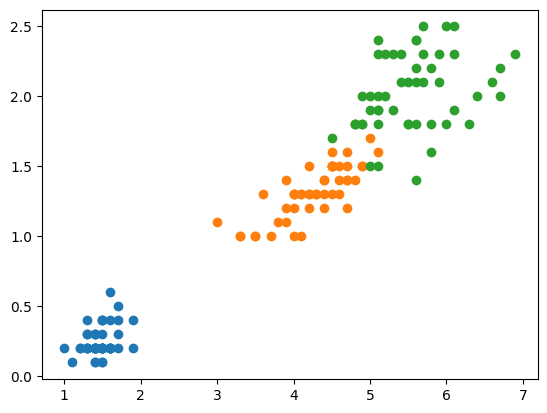

In [46]:
plt.scatter(setosa[:, 0], setosa[:, 1])
plt.scatter(versicolor[:, 0], versicolor[:,1])
plt.scatter(virginica[:, 0], virginica[:,1])
plt.scatter(4.9, 1.5, marker='D', c='B')
plt.scatter(4.9, 1.7, marker='D', c='R')
plt.xlabel('PetalLength')
plt.ylabel('PetalWidth')
plt.legend(['Setosa', 'Versicolor', 'Virginica'])
plt.show()

In [ ]:
new = np.array([[4.9, 1.5], [4.9, 1.7]])
new_scaled = ss.transform(new)

In [ ]:
kn.predict(new_scaled)

In [ ]:
kn.predict_proba(new_scaled)